# TFG V3 — First global interference test

This version keeps the ND loader from V2 and adds the first global interference experiment. The goal is to test whether an oracle-style phase or auxiliary operation can reshape amplitudes after the window superposition has been prepared.

## Problem model

The search space is still the set of valid ND window starts. Each branch contains the fixed grid, the candidate index, and the loaded window:

```text
sum_i |grid>|idx=i>|window_i>
```

## Circuit structure

1. Prepare the grid and the uniform superposition over valid indices.
2. Load the corresponding window into `m`.
3. Prepare an auxiliary qubit for phase kickback.
4. Apply a simple oracle/interference block.
5. Mix the index register and inspect the resulting state.

## Registers and data

- `n`: fixed ND grid with free and occupied cells.
- `idx`: candidate window-start index.
- `m`: loaded candidate window.
- `aux`: auxiliary qubit used by the oracle/interference block.

## Purpose of this version

V3 is a bridge between the loader-only notebooks and the later parametrized strategies. It keeps the interference block simple so the role of phase kickback, uncomputation, and index mixing can be inspected directly.

In [20]:
import time
import qiskit
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, AncillaRegister
from qiskit.quantum_info import Statevector, SparsePauliOp, partial_trace
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
# DISABLED: IBM Runtime import; using simulators only. from qiskit_ibm_runtime import EstimatorV2 as Estimator
# DISABLED: IBM Runtime import; using simulators only. from qiskit_ibm_runtime import SamplerV2 as Sampler
# DISABLED: IBM Runtime import; using simulators only. from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
from itertools import product
from math import prod

print(qiskit.__version__)

2.3.1


In [21]:
# =========================================================
# ND geometry, loading, and display helpers
# =========================================================

def superposition():
    current_zero_mask = [False] * IDX  # False means no X is currently applied to idx[b].

    for i in order_valid:
        bits = [(i >> b) & 1 for b in range(IDX)]   # little-endian
        target_zero_mask = [bits[b] == 0 for b in range(IDX)]
        win = window_qubits_nd(starts[i], N, M)

        # Toggle only idx controls whose zero-mask state changes.
        for b in range(IDX):
            if current_zero_mask[b] != target_zero_mask[b]:
                qc.x(idx[b])
                current_zero_mask[b] = target_zero_mask[b]

        # Copy the window onto m with XOR
        for j, n_pos in enumerate(win):
            controls = [idx[b] for b in range(IDX)] + [n[n_pos]]
            qc.mcx(controls, m[j])

    # Clear the final X pattern on idx
    for b in range(IDX):
        if current_zero_mask[b]:
            qc.x(idx[b])

def index_to_coord(index, dims):
    """
    Converts a row-major linear index to a D-dimensional coordinate.
    """
    coord = [0] * len(dims)
    rem = index
    for d in reversed(range(len(dims))):
        coord[d] = rem % dims[d]
        rem //= dims[d]
    return tuple(coord)

def coord_to_index(coord, dims):
    """
    Converts a D-dimensional coordinate to a row-major linear index.
    """
    idx_lin = 0
    stride = 1
    for d in reversed(range(len(dims))):
        idx_lin += coord[d] * stride
        stride *= dims[d]
    return idx_lin

def reshape_bits_nd(bitstring, dims):
    """
    Reorganiza un bitstring lineal row-major a una estructura anidada
    con forma dims.
    """
    arr = np.array(list(bitstring), dtype=str)
    return arr.reshape(dims)

def format_nd_array(arr, indent=0):
    """
    Formats an ndarray/string-array of any dimension in a readable way.
    """
    if arr.ndim == 1:
        return "[" + " ".join(arr.tolist()) + "]"

    inner = []
    for sub in arr:
        inner.append(format_nd_array(np.array(sub), indent + 2))

    sep = ",\n" + " " * indent
    return "[\n" + " " * indent + sep.join(inner) + "\n" + " " * max(indent - 2, 0) + "]"

def format_nd_array_inline(arr):
    """
    Compact version of format_nd_array to print an ND window on one line.
    """
    return " ".join(format_nd_array(arr).split())

def valid_starts_nd(N, M):
    """
    List of valid starting coordinates for the window in D dimensions.
    Usa la misma convencion row-major.
    """
    shape_starts = tuple(N[d] - M[d] + 1 for d in range(len(N)))
    return list(np.ndindex(shape_starts))

def window_qubits_nd(start, N, M):
    """
    Returns the linear qubit indices of the window that starts at 'start',
    en orden row-major dentro del bloque M.

    2D example with M=[2,2]:
    offsets visitados:
        (0,0), (0,1), (1,0), (1,1)
    """
    qubits = []
    for offset in np.ndindex(tuple(M)):
        coord = tuple(start[d] + offset[d] for d in range(len(N)))
        qubits.append(coord_to_index(coord, N))
    return qubits

def print_state_grouped(sv, title="SUPERPOSED STATES", tol=1e-10):
    print(f"\n============ {title} ============")

    total_qubits = int(np.log2(len(sv.data)))
    shown_qubits = total_qubits - N_tot

    if shown_qubits < AUX + M_tot + IDX:
        raise ValueError("The register sizes do not match the displayed total number of qubits.")

    filas = []

    for i, amp in enumerate(sv.data):
        if abs(amp) <= tol:
            continue

        bits_full = format(i, f"0{total_qubits}b")
        bits = bits_full[:shown_qubits]

        pos = 0
        aux_bits = bits[pos:pos + AUX]
        pos += AUX

        m_desc = bits[pos:pos + M_tot]
        pos += M_tot

        idx_bits = bits[pos:pos + IDX]   # Standard binary order for sorting.
        pos += IDX

        window_bits = m_desc[::-1]     # Display as m_0...m_{M_tot-1}.
        window_nd = format_nd_array_inline(reshape_bits_nd(window_bits, M))
        idx_int = int(idx_bits, 2)
        start = starts[idx_int] if idx_int < W else None

        filas.append((idx_int, idx_bits, aux_bits, window_bits, window_nd, start, amp))

    filas.sort(key=lambda x: (x[0], x[3], x[6].real, x[6].imag))

    for idx_int, idx_bits, aux_bits, window_bits, window_nd, start, amp in filas:
        start_txt = f" start={start}" if start is not None else " start=INVALID"
        print(f"{amp.real: .4g} aux=|{aux_bits}> window=|{window_bits}> window_nd={window_nd} index=|{idx_bits}> ({idx_int}){start_txt}")

Dimensions: 1
Grid size per dimension: [5]
Job/window size per dimension: [2]
Total cells: 5
Total job/window cells: 2
Total possible windows: 4
Qubits required to represent the windows: 2

Possible valid windows (start coordinate):
0: (0,) -> [0, 1]
1: (1,) -> [1, 2]
2: (2,) -> [2, 3]
3: (3,) -> [3, 4]

Gray-like order used to load windows:
[0, 1, 3, 2]


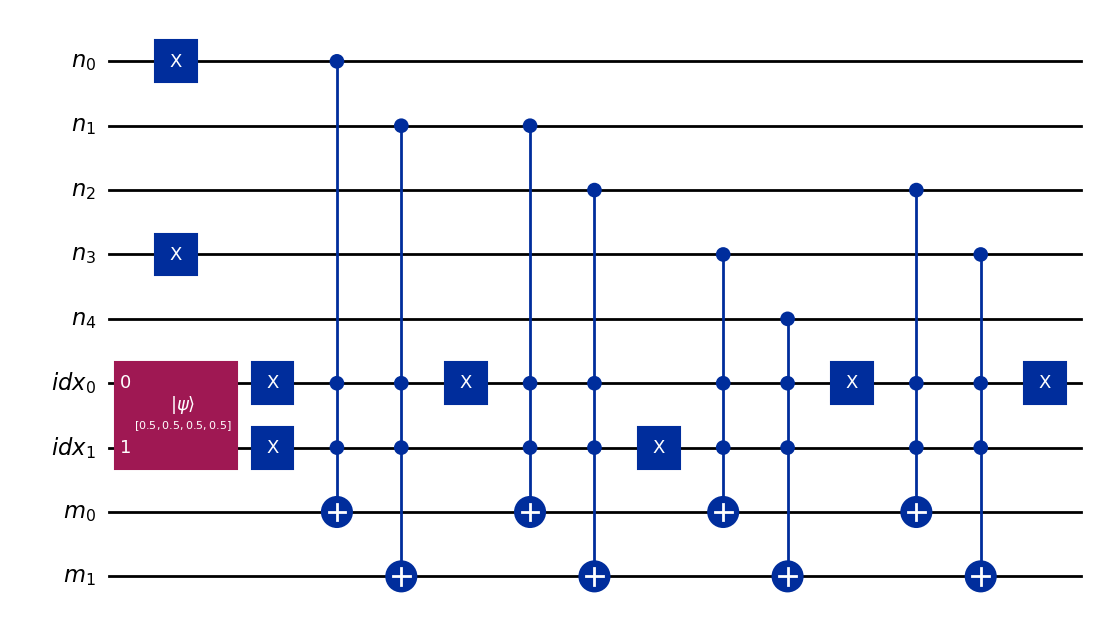

In [22]:
# =========================
# Parameters
# =========================

D = 1
N = [5]   # grid size in each dimension
M = [2]   # job/window size in each dimension

if len(N) != D or len(M) != D:
    raise ValueError("N y M deben tener longitud D")

for d in range(D):
    if M[d] > N[d]:
        raise ValueError(f"In dimension {d}, M[{d}] cannot be greater than N[{d}]")

# Total number of cells (grid and work register) and valid windows in D dimensions
N_tot = prod(N)
M_tot = prod(M)
starts = valid_starts_nd(N, M)
W = len(starts)

# Required index qubits
IDX = int(np.ceil(np.log2(W))) if W > 1 else 1
AUX = 1

print(f"Dimensions: {D}")
print(f"Grid size per dimension: {N}")
print(f"Job/window size per dimension: {M}")
print(f"Total cells: {N_tot}")
print(f"Total job/window cells: {M_tot}")
print(f"Total possible windows: {W}")
print(f"Qubits required to represent the windows: {IDX}")

print("\nPossible valid windows (start coordinate):")
for idx_start, start in enumerate(starts):
    print(f"{idx_start}: {start} -> {window_qubits_nd(start, N, M)}")

# =========================
# Registers
# =========================

n = QuantumRegister(N_tot, "n")   # grid
idx = QuantumRegister(IDX, "idx")     # window index
m = QuantumRegister(M_tot, "m")   # work window
aux = QuantumRegister(AUX, "aux")   # auxiliary qubit

qc = QuantumCircuit(n, idx, m)#, aux)

# =========================
# Example initial state
# =========================

qc.x(n[0])
qc.x(n[3])

# 2x2 square at (0,0), valid for grids with N[d] >= 2
# qc.x(n[0])
# qc.x(n[1])
# qc.x(n[4])
# qc.x(n[5])

# 2x2 square at (2,1), example for sufficiently large 2D grids
# qc.x(n[9])
# qc.x(n[10])
# qc.x(n[13])
# qc.x(n[14])

# N=3x3
# qc.x(n[0])
# qc.x(n[2])
# qc.x(n[8])

# N=4x4
# qc.x(n[0])
# qc.x(n[2])
# qc.x(n[3])
# qc.x(n[4])
# qc.x(n[5])
# qc.x(n[8])
# qc.x(n[9])
# qc.x(n[14])
# qc.x(n[15])

# =========================
# Valid-index superposition
# =========================
# Prepares:
#   (1/sqrt(W)) * sum_{i=0}^{W-1} |i>
# Invalid indices i >= W keep zero amplitude.

amps_idx = np.zeros(2**IDX, dtype=complex)
amps_idx[:W] = 1 / np.sqrt(W)
qc.initialize(amps_idx, idx)

# =========================
# Gray-like order to minimize X gates on idx
# =========================
# Traverse valid indices in Gray-like order:
# Take the full Gray sequence over IDX bits and keep values below W.

gray_full = [t ^ (t >> 1) for t in range(2**IDX)]
order_valid = [g for g in gray_full if g < W]

print("\nGray-like order used to load windows:")
print(order_valid)

# =========================
# Coherent window loading
# =========================
# Instead of:
#   activating X according to i
#   applying MCX
#   undoing X
# for each i,
# we keep the current X pattern on idx and only change
# the bits that actually vary between one window and the next.

superposition()

qc.draw(output='mpl')

In [23]:
sv = Statevector(qc)
sv.draw(output='latex', max_size=2**qc.num_qubits, prefix="|\\psi\\rangle = ")

<IPython.core.display.Latex object>

In [5]:
# =========================================================
# 1) Remove the n register
# =========================================================
rho = partial_trace(sv, list(range(N_tot)))

# =========================================================
# 2) Check purity
# =========================================================
purity = np.real(np.trace(rho.data @ rho.data))
print(f"Purity = {purity}")

if not np.isclose(purity, 1.0, atol=1e-10):
    raise ValueError("El estado reducido no es puro; no se puede representar como un unico ket.")

# =========================================================
# 3) Extract the complete n-position array
# =========================================================
tol_n = 1e-10
total_q = qc.num_qubits
array_posiciones = None

for basis_idx, amp in enumerate(sv.data):
    if abs(amp) <= tol_n:
        continue

    bits_full = format(basis_idx, f'0{total_q}b')

    # In Qiskit, the string is returned as:
    # m_{M_tot-1}...m_0  i_{IDX-1}...i_0  n_{N_tot-1}...n_0
    # Therefore the n qubits are at the end.
    n_desc = bits_full[-N_tot:]    # n_{N_tot-1}...n_0
    n_asc = n_desc[::-1]           # n_0...n_{N_tot-1}

    if array_posiciones is None:
        array_posiciones = n_asc
    elif n_asc != array_posiciones:
        raise ValueError("The n qubits are not deterministic (there is no unique position array).")

if array_posiciones is None:
    raise ValueError("Could not infer the position array from the statevector.")

print(f"Linear position array = {array_posiciones}\n")

# Also display the grid with shape N
red_nd = reshape_bits_nd(array_posiciones, N)
print(f"Red con forma {tuple(N)}:")
print(format_nd_array(red_nd))
print()

# =========================================================
# 4) Extract the ket of the reduced state
# =========================================================
vals, vecs = np.linalg.eigh(rho.data)
psi_red = Statevector(vecs[:, np.argmax(vals)])

# =========================================================
# 5) Extract labels from the reduced state
# =========================================================
# In psi_red, the binary string has the form:
# m_{M_tot-1}...m_0  i_{IDX-1}...i_0
total_bits = M_tot + IDX
tol = 1e-10
filas = []

for basis_idx, amp in enumerate(psi_red.data):
    if abs(amp) <= tol:
        continue

    bits = format(basis_idx, f'0{total_bits}b')

    m_desc = bits[:M_tot]     # m_{M_tot-1}...m_0
    i_desc = bits[M_tot:]     # i_{IDX-1}...i_0

    ventana_lineal = m_desc[::-1]   # m_0...m_{M_tot-1}
    indices = i_desc
    idx_int = int(indices, 2)

    filas.append((idx_int, indices, ventana_lineal))

# Sort by the integer value of the index
filas.sort(key=lambda x: (x[0], x[2]))

# Split rows by index validity.
filas_validas = [fila for fila in filas if fila[0] < W]
filas_invalidas = [fila for fila in filas if fila[0] >= W]

# =========================================================
# 6) Display valid windows with ND shape
# =========================================================
print("Valid windows:\n")

for idx_int, indices, ventana_lineal in filas_validas:
    start = starts[idx_int]   # ND start coordinate corresponding to this index
    ventana_nd = reshape_bits_nd(ventana_lineal, M)

    print(f"Index: {indices} ({idx_int})")
    print(f"Start:  {start}")
    print(f"Ventana lineal: {ventana_lineal}")
    print(f"Ventana con forma {tuple(M)}:")
    print(format_nd_array(ventana_nd))
    print()

# =========================================================
# 7) Display invalid-index rows, if any
# =========================================================
if filas_invalidas:
    print("----------------------------------------")
    print("Indices outside the valid window range:\n")

    for idx_int, indices, ventana_lineal in filas_invalidas:
        ventana_nd = reshape_bits_nd(ventana_lineal, M)

        print(f"Index: {indices} ({idx_int})")
        print(f"Ventana lineal: {ventana_lineal}")
        print(f"Ventana con forma {tuple(M)}:")
        print(format_nd_array(ventana_nd))
        print()

Purity = 0.9999999999999957
Linear position array = 1001

Red con forma (4,):
[1 0 0 1]

Valid windows:

Index: 00 (0)
Start:  (0,)
Ventana lineal: 10
Ventana con forma (2,):
[1 0]

Index: 01 (1)
Start:  (1,)
Ventana lineal: 00
Ventana con forma (2,):
[0 0]

Index: 10 (2)
Start:  (2,)
Ventana lineal: 01
Ventana con forma (2,):
[0 1]



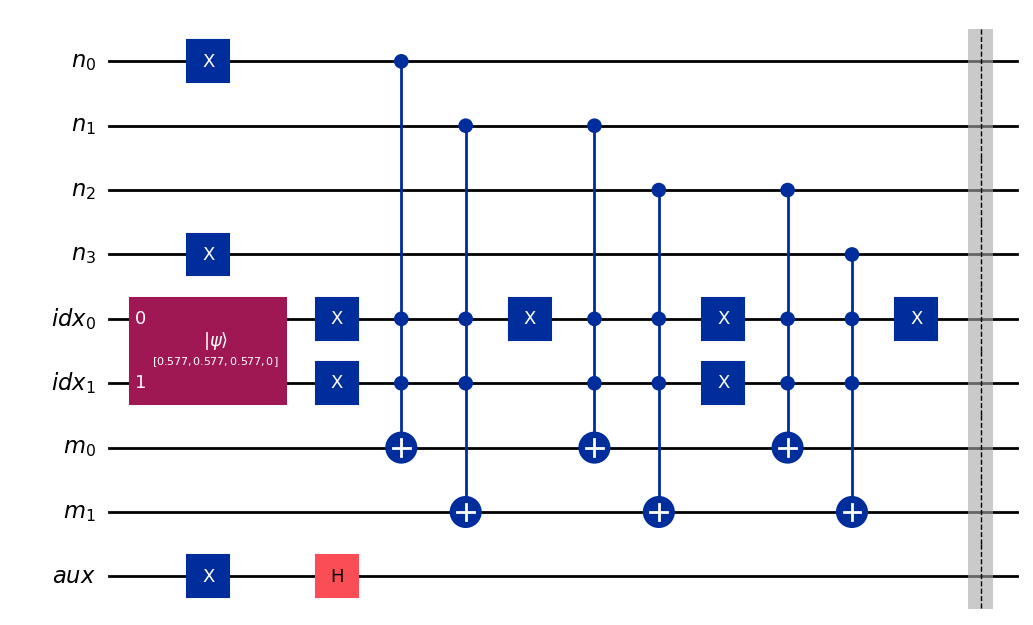

In [6]:
qc.x(aux)
qc.h(aux)
qc.barrier()
qc.draw(output='mpl')

In [7]:
sv = Statevector(qc)
print_state_grouped(sv)


============ SUPERPOSED STATES ============
-0.4082 aux=|1> window=|10> window_nd=[1 0] index=|00> (0) start=(0,)
 0.4082 aux=|0> window=|10> window_nd=[1 0] index=|00> (0) start=(0,)
-0.4082 aux=|1> window=|00> window_nd=[0 0] index=|01> (1) start=(1,)
 0.4082 aux=|0> window=|00> window_nd=[0 0] index=|01> (1) start=(1,)
-0.4082 aux=|1> window=|01> window_nd=[0 1] index=|10> (2) start=(2,)
 0.4082 aux=|0> window=|01> window_nd=[0 1] index=|10> (2) start=(2,)


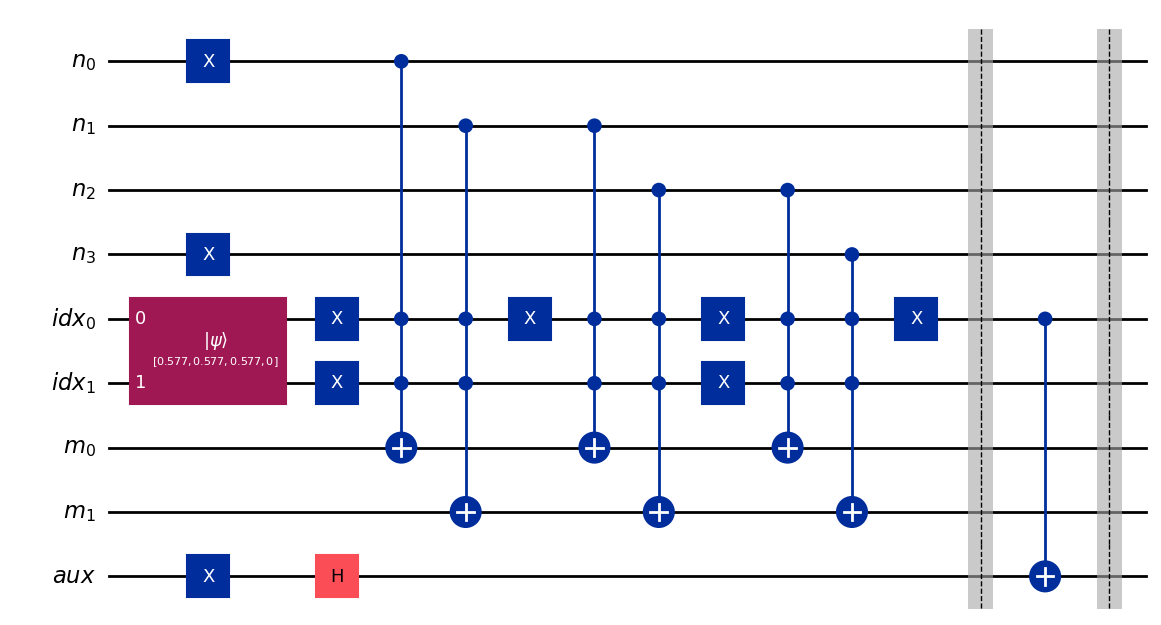

In [8]:
# def oracle_gate():
#     if IDX <= 1:
#         raise ValueError("The current oracle uses idx[1], but IDX <= 1.")

#     oracle = QuantumCircuit(IDX + AUX, name="U_f")

#     # Temporary oracle: marks states with i_1 = 1 on the auxiliary qubit.
#     oracle.cx(1, IDX)
#     return oracle.to_gate(label="U_f")

# qc.append(oracle_gate(), list(idx) + list(aux))

qc.cx(idx[0], aux)
qc.barrier()
qc.draw(output='mpl')

In [9]:
sv = Statevector(qc)
print_state_grouped(sv)


============ SUPERPOSED STATES ============
-0.4082 aux=|1> window=|10> window_nd=[1 0] index=|00> (0) start=(0,)
 0.4082 aux=|0> window=|10> window_nd=[1 0] index=|00> (0) start=(0,)
-0.4082 aux=|0> window=|00> window_nd=[0 0] index=|01> (1) start=(1,)
 0.4082 aux=|1> window=|00> window_nd=[0 0] index=|01> (1) start=(1,)
-0.4082 aux=|1> window=|01> window_nd=[0 1] index=|10> (2) start=(2,)
 0.4082 aux=|0> window=|01> window_nd=[0 1] index=|10> (2) start=(2,)


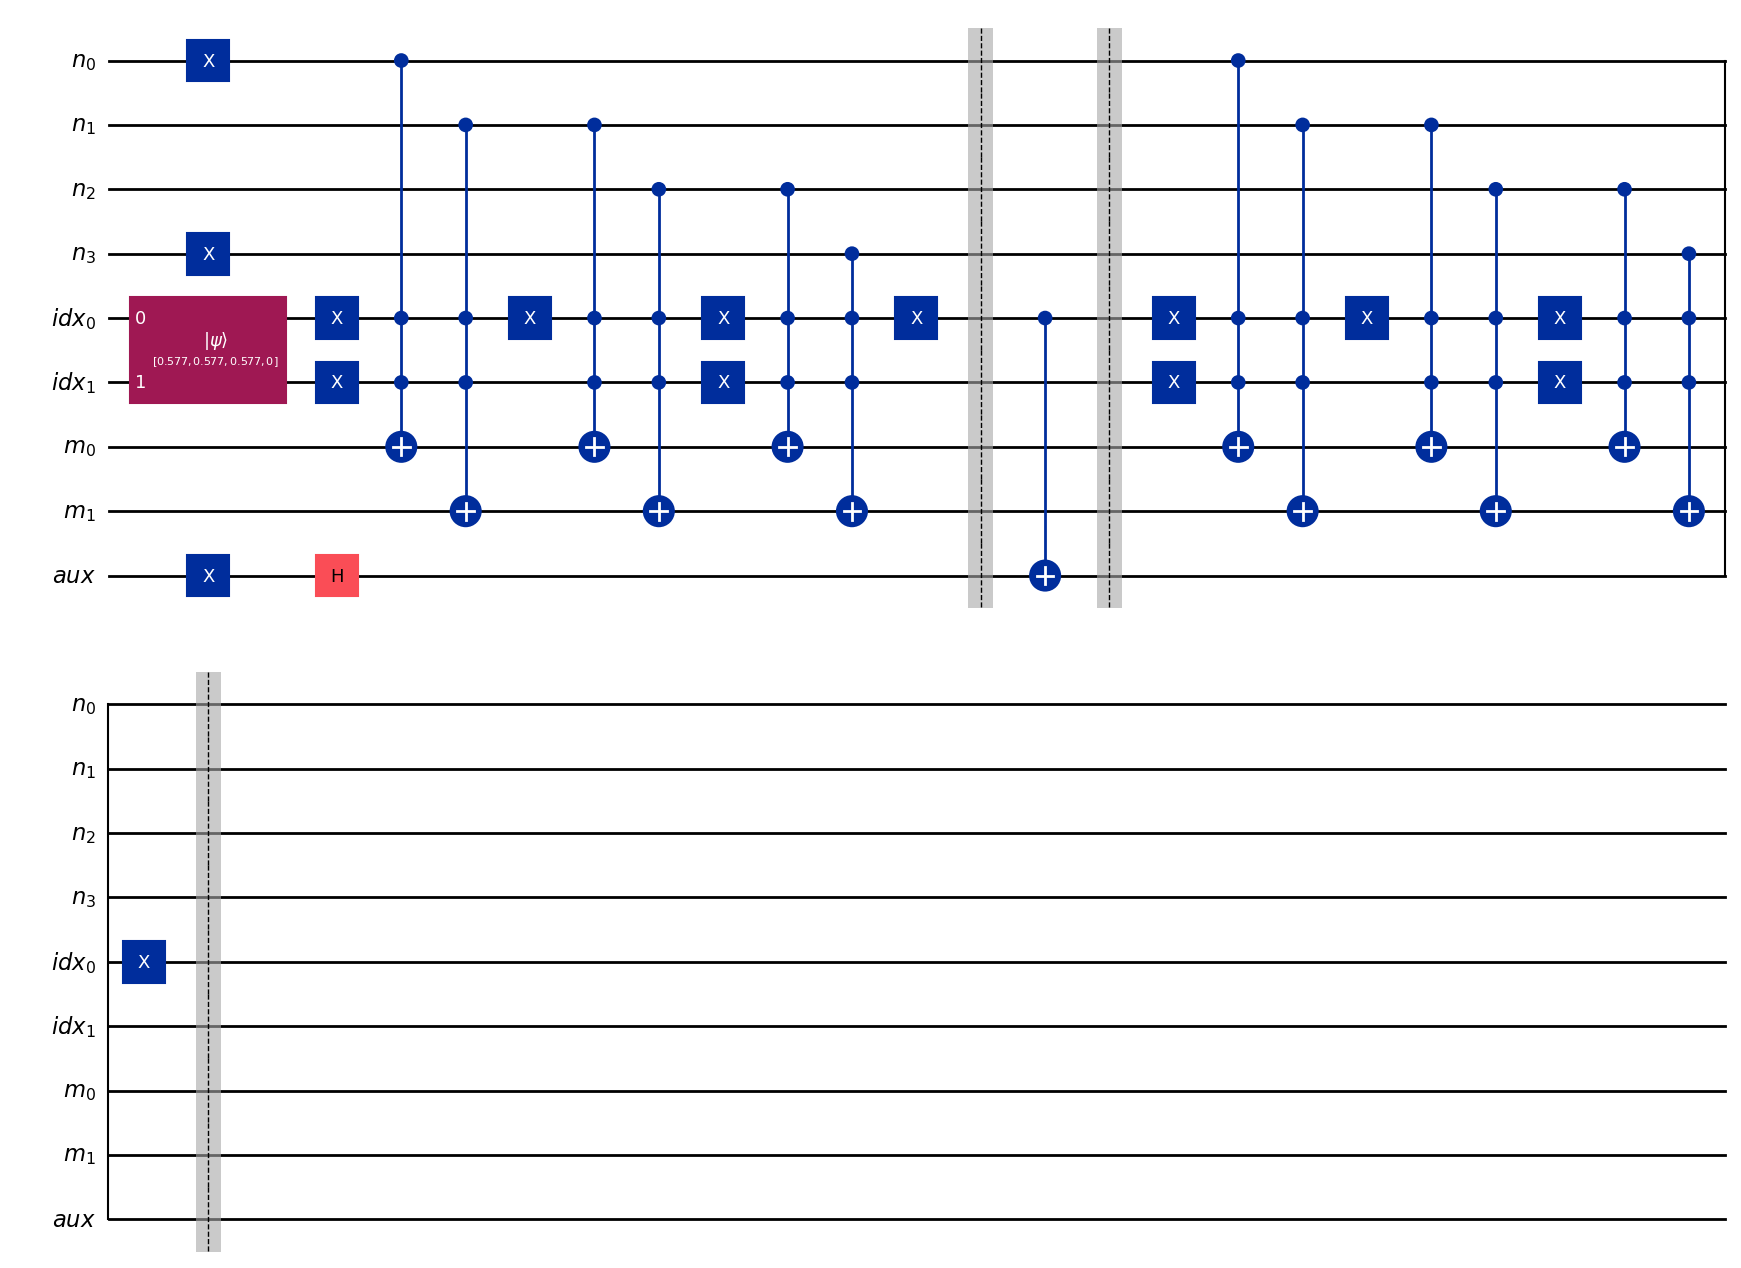

In [10]:
superposition()
qc.barrier()
qc.draw(output='mpl')

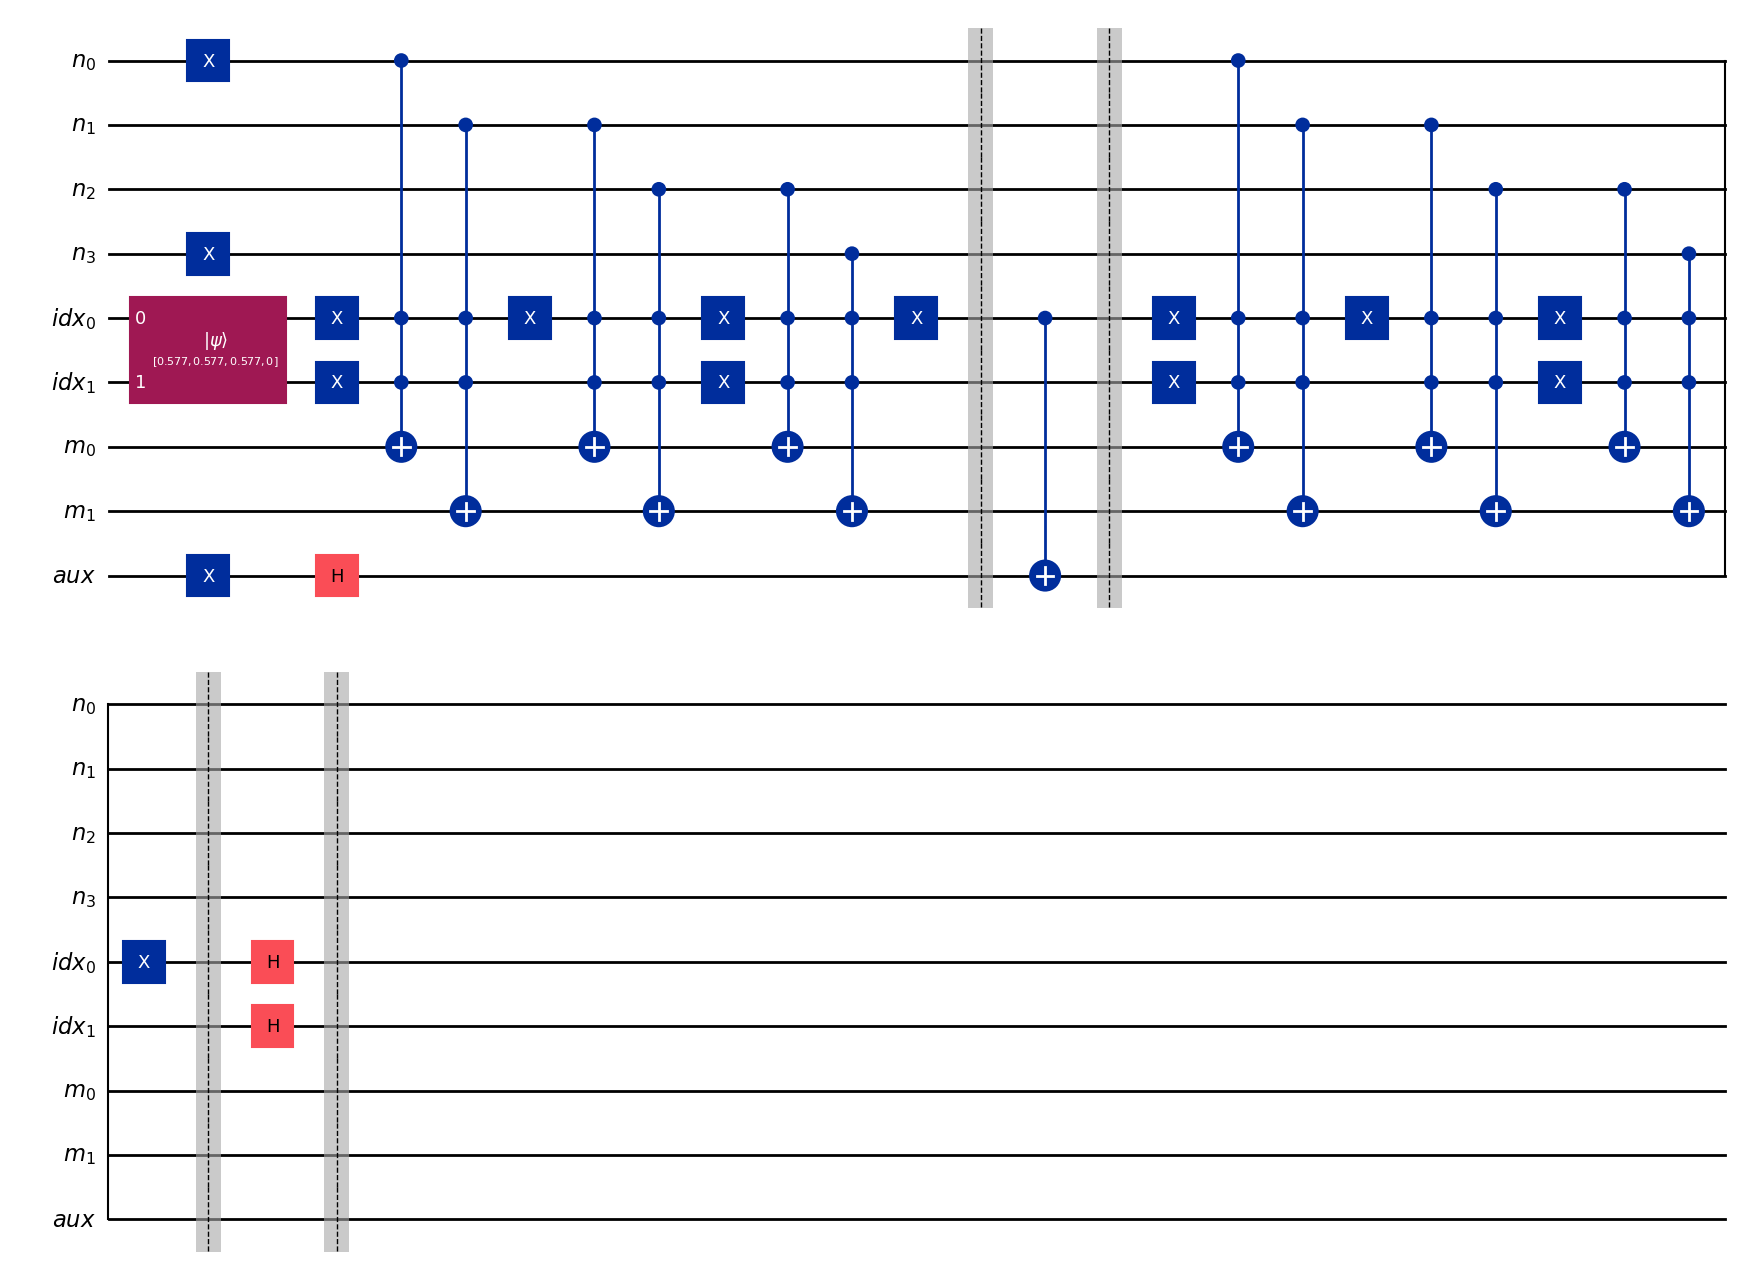

In [11]:
qc.h(idx)
qc.barrier()
qc.draw(output='mpl')

In [12]:
sv = Statevector(qc)
print_state_grouped(sv)


============ SUPERPOSED STATES ============
-0.2041 aux=|1> window=|00> window_nd=[0 0] index=|00> (0) start=(0,)
 0.2041 aux=|0> window=|00> window_nd=[0 0] index=|00> (0) start=(0,)
-0.6124 aux=|1> window=|00> window_nd=[0 0] index=|01> (1) start=(1,)
 0.6124 aux=|0> window=|00> window_nd=[0 0] index=|01> (1) start=(1,)
-0.2041 aux=|0> window=|00> window_nd=[0 0] index=|10> (2) start=(2,)
 0.2041 aux=|1> window=|00> window_nd=[0 0] index=|10> (2) start=(2,)
-0.2041 aux=|1> window=|00> window_nd=[0 0] index=|11> (3) start=INVALID
 0.2041 aux=|0> window=|00> window_nd=[0 0] index=|11> (3) start=INVALID


In [13]:
sv = Statevector(qc)
sv.draw(output='latex', max_size=2**qc.num_qubits, prefix="|\\psi\\rangle = ")

<IPython.core.display.Latex object>

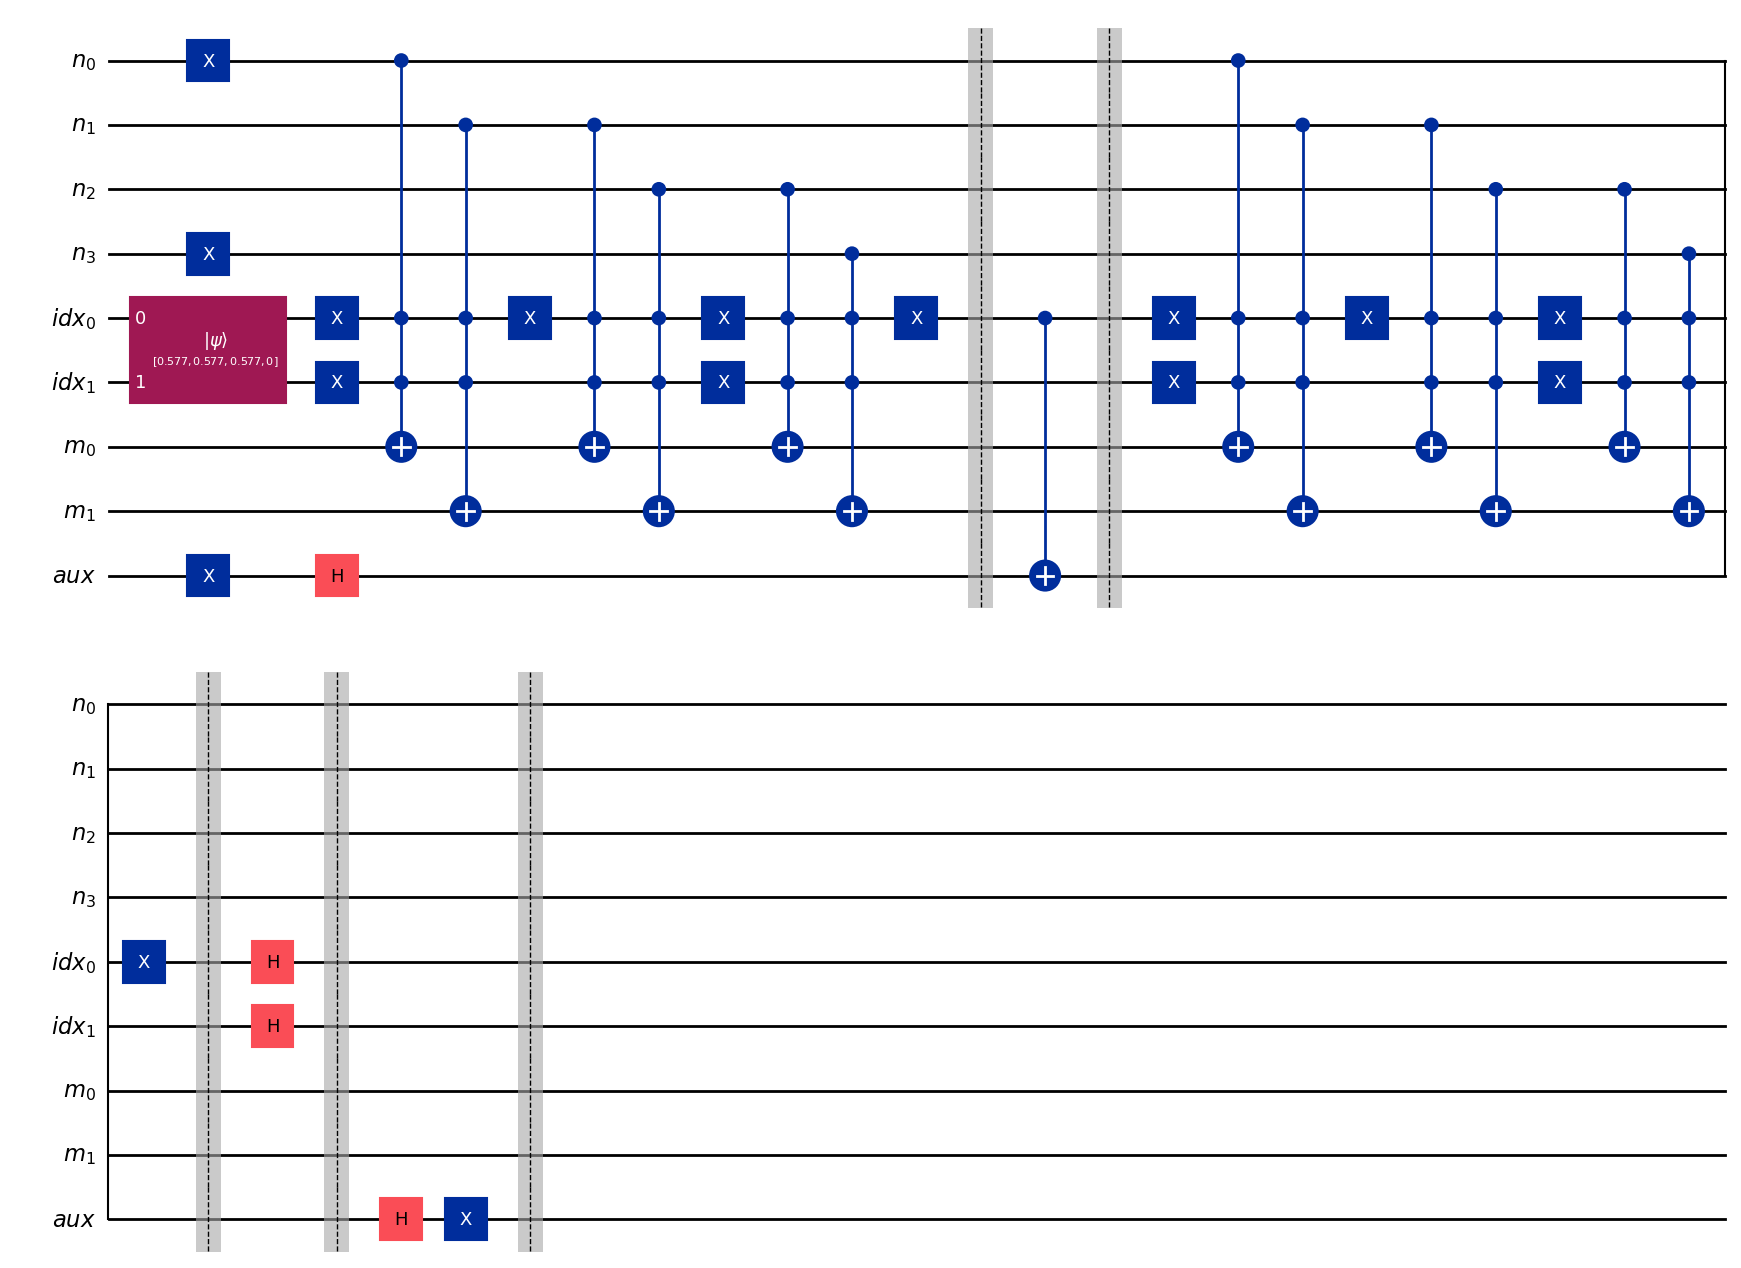

In [14]:
qc.h(aux)
qc.x(aux)
qc.barrier()
qc.draw(output='mpl')

In [15]:
sv = Statevector(qc)
print_state_grouped(sv)


============ SUPERPOSED STATES ============
 0.2887 aux=|0> window=|00> window_nd=[0 0] index=|00> (0) start=(0,)
 0.866 aux=|0> window=|00> window_nd=[0 0] index=|01> (1) start=(1,)
-0.2887 aux=|0> window=|00> window_nd=[0 0] index=|10> (2) start=(2,)
 0.2887 aux=|0> window=|00> window_nd=[0 0] index=|11> (3) start=INVALID
